In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =====================================
# 📘 KNN Classification Baseline (No SMOTE/ADASYN)
# =====================================

#Cell 1: Import Libraries
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from collections import Counter

In [4]:
#Cell 2: Load Dataset
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("✅ Data Loaded Successfully!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

✅ Data Loaded Successfully!
Train shape: (329623, 13)
Test shape: (82406, 13)


In [5]:
#Cell 3: Split Features & Target
target_col = "PM2.5_level"
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test  = df_test.drop(columns=[target_col])
y_test  = df_test[target_col]

print("\nClass Distribution in Train Set:", Counter(y_train))


Class Distribution in Train Set: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})


In [6]:
# ===========================================
# 🧩 Cell 4: 10-Fold Cross Validation + Mean/SD
# ===========================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []

print("=== 10-Fold Cross Validation Results ===")

X_train = np.array(X_train)
y_train = np.array(y_train)
classes = np.unique(y_train)

start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = KNeighborsClassifier(n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted')

    y_val_bin = label_binarize(y_val, classes=sorted(classes))
    y_pred_bin = label_binarize(y_pred, classes=sorted(classes))
    fold_auc = roc_auc_score(y_val_bin, y_pred_bin, average="weighted", multi_class="ovr")

    results.append([fold, acc, prec, rec, f1, fold_auc])
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(fold_auc)

# 🧾 สร้าง DataFrame สำหรับแต่ละ fold
cv_df = pd.DataFrame(results, columns=["Fold", "Accuracy", "Precision", "Recall", "F1", "AUC_ROC"])
print(cv_df)

# 📈 คำนวณ Mean และ SD ของแต่ละ metric
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

# 📊 แสดงผลรวมทั้งหมด
print("\n📊 Cross-validation (10 folds) Avg Metrics:")
print(f"Accuracy: {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall: {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1: {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC: {auc_mean:.3f} ± {auc_sd:.3f}")

end_time = time.time()
print(f"\n⏱ Completed in {end_time - start_time:.2f} seconds")



=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.726815   0.717783  0.726815  0.721124  0.826868
1     2  0.730000   0.720961  0.730000  0.724193  0.829441
2     3  0.727907   0.718927  0.727907  0.722128  0.827232
3     4  0.728991   0.719761  0.728991  0.723014  0.827921
4     5  0.726139   0.716764  0.726139  0.720284  0.826347
5     6  0.730629   0.722521  0.730629  0.725545  0.829163
6     7  0.728688   0.720732  0.728688  0.723548  0.828343
7     8  0.728597   0.720645  0.728597  0.723428  0.828264
8     9  0.724774   0.715776  0.724774  0.718982  0.825529
9    10  0.726534   0.717475  0.726534  0.720513  0.826757

📊 Cross-validation (10 folds) Avg Metrics:
Accuracy: 0.728 ± 0.002
Precision: 0.719 ± 0.002
Recall: 0.728 ± 0.002
F1: 0.722 ± 0.002
AUC: 0.828 ± 0.001

⏱ Completed in 123.10 seconds


In [7]:
#Cell 5: Final Testing & Report
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(classes))
y_pred_test_bin = label_binarize(y_pred_test, classes=sorted(classes))
test_auc = roc_auc_score(y_test_bin, y_pred_test_bin, average="weighted", multi_class="ovr")

print(f"\n📈 Test Set Metrics:")
print(f"Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=2))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



📈 Test Set Metrics:
Accuracy: 0.731, Precision: 0.722, Recall: 0.731, F1: 0.725, AUC: 0.830

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80     16078
           2       0.43      0.38      0.40      8376
           3       0.41      0.34      0.37      7486
           4       0.66      0.66      0.66     18265
           5       0.89      0.89      0.89     32201

    accuracy                           0.73     82406
   macro avg       0.63      0.63      0.63     82406
weighted avg       0.72      0.73      0.73     82406

Confusion Matrix:
[[13816  1620   338   241    63]
 [ 3270  3167  1176   720    43]
 [  940  1732  2566  2071   177]
 [  446   841  1916 11973  3089]
 [   52    75   205  3143 28726]]


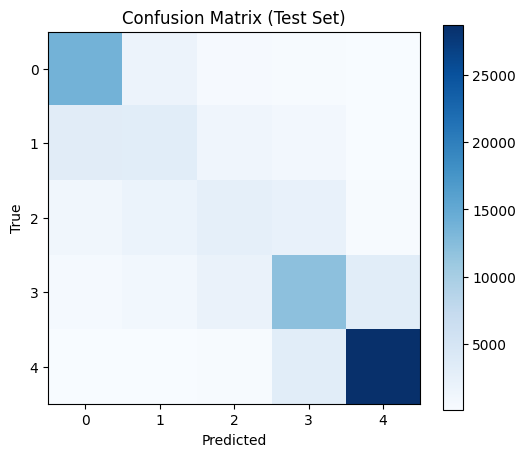

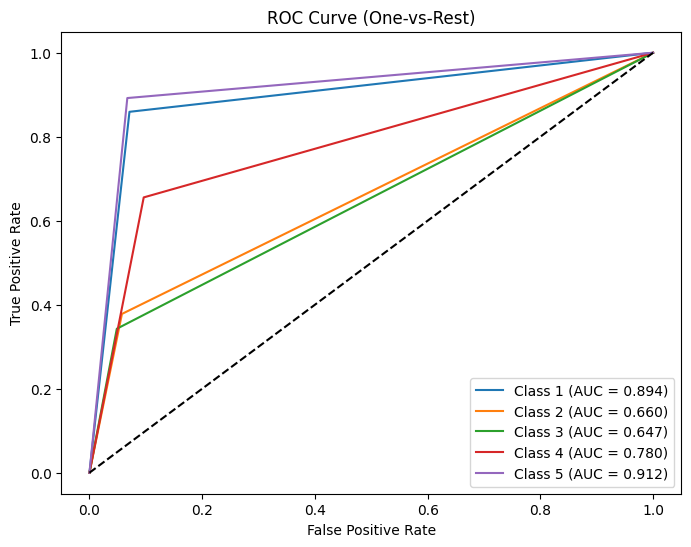

In [8]:
#Cell 6: Confusion Matrix & ROC Curve
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

n_classes = len(classes)
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_test_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()


In [10]:
#Cell 7: Save Model, AUC & ROC Data
base_path = '/content/drive/MyDrive/Senior_Project/roc/'

joblib.dump(model, base_path + 'knn_baseline.pkl')
print(f"\n💾 Model saved as {base_path}knn_baseline.pkl")

auscsv = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [test_auc]
})
auscsv.to_csv(base_path + 'knn_baseline_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}knn_baseline_auc.csv")

roc_data = []
for i in range(n_classes):
    df_temp = pd.DataFrame({
        'Class': [classes[i]] * len(fpr[i]),
        'FPR': fpr[i],
        'TPR': tpr[i]
    })
    roc_data.append(df_temp)

roc_df = pd.concat(roc_data, ignore_index=True)
roc_df.to_csv(base_path + 'knn_baseline_roc_data.csv', index=False)
print(f"💾 ROC curve data saved to {base_path}knn_baseline_roc_data.csv")
# 💾 บันทึกเป็น DataFrame รวม mean+sd ไว้ในไฟล์เพิ่ม (optional)
summary_df = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

summary_df.to_csv(base_path + "knn_baseline_mean_sd.csv", index=False)
print(f"💾 Mean + SD saved to {base_path}knn_baseline_mean_sd.csv")


💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/knn_baseline.pkl
💾 AUC-ROC values saved to /content/drive/MyDrive/Senior_Project/roc/knn_baseline_auc.csv
💾 ROC curve data saved to /content/drive/MyDrive/Senior_Project/roc/knn_baseline_roc_data.csv
💾 Mean + SD saved to /content/drive/MyDrive/Senior_Project/roc/knn_baseline_mean_sd.csv
